# A. Import AUTOECONSENTIMENT

In [52]:
import os
import pandas as pd
import yaml
from auto_econ_sentiment.pipeline import AutoEconSentiment
from auto_econ_sentiment.utils.load_yaml import load_yaml_config

# Ensure we are in the project root if running from notebooks directory
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/cory/Desktop/auto-econ-sentiment


## A.1 Synthetic example

In [57]:
# Create synthetic data for demonstration
data = {
    "text": [
        "Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.", 
        "Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",
        "Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",
        "The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.",
        "Economic activity increased fast while maintaining high employment and strong consumer confidence.",
        "Slower growth and weak demand were observed in the second half of the year, leading to low inflation."
    ],
    "date": ["2024-01-01", "2024-02-01", "2024-03-01", "2024-04-01", "2024-05-01", "2024-06-01"]
}
df_demo = pd.DataFrame(data)
csv_demo_path = "data/temp/demo_data.csv"
os.makedirs("data/temp", exist_ok=True)
df_demo.to_csv(csv_demo_path, index=False)
df_demo.head()

,text,date
0,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",2024-01-01
1,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",2024-02-01
2,"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",2024-03-01
3,The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,2024-04-01
4,Economic activity increased fast while maintaining high employment and strong consumer confidence.,2024-05-01


# 1. Run autoecon sentiment
## 1.A Initialize autoecon sentiment

In [54]:
# Initialize AutoEconSentiment
analyzer = AutoEconSentiment(
    import_file_path=csv_demo_path,
    text_column="text",
    date_column="date",
    export_path="data/temp/lexical_results"
)
# Load data
df_raw = analyzer.load_data()
df_raw.head(2)

,text,date
0,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",2024-01-01
1,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",2024-02-01


## 1.1 Clean

In [55]:
# Clean data
# We'll use a basic cleaning configuration
clean_config = {
    "clean_html": True,
    "clean_numbers_percentages": True,
    "remove_headers": [],
    "tokenize": True,
    "stem": True
}

df_clean, df_sentences = analyzer.clean_data(clean_config=clean_config)
df_clean.head()

Tokenizing sentences: 100%|██████████| 6/6 [00:00<00:00, 17797.61it/s]


,text,date,id_text,text_clean,text_tokens,text_tokens_str,text_stems,text_sentences
0,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",2024-01-01,1,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.","[economic, growth, remains, robust, despite, global, challenges, the, central, bank, is, committed, to, price, stability, however, uncertainties, persist, regarding, geopolitical, tensions]",economic growth remains robust despite global challenges the central bank is committed to price stability however uncertainties persist regarding geopolitical tensions,econom growth remain robust despit global challeng the central bank is commit to price stabil howev uncertainti persist regard geopolit tension,"[Economic growth remains robust despite global challenges., The central bank is committed to price stability., However, uncertainties persist regarding geopolitical tensions.]"
1,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",2024-02-01,2,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.","[inflationary, pressures, have, eased, slightly, but, remain, above, target, recent, indicators, suggest, a, softening, in, labor, markets]",inflationary pressures have eased slightly but remain above target recent indicators suggest a softening in labor markets,inflationari pressur have eas slightli but remain abov target recent indic suggest a soften in labor market,"[Inflationary pressures have eased slightly, but remain above target., Recent indicators suggest a softening in labor markets.]"
2,"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",2024-03-01,3,"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.","[our, latest, projections, indicate, a, moderate, recovery, however, uncertainties, persist, regarding, geopolitical, tensions]",our latest projections indicate a moderate recovery however uncertainties persist regarding geopolitical tensions,our latest project indic a moder recoveri howev uncertainti persist regard geopolit tension,"[Our latest projections indicate a moderate recovery., However, uncertainties persist regarding geopolitical tensions.]"
3,The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,2024-04-01,4,The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,"[the, committee, decided, to, maintain, interest, rates, at, their, current, levels, to, support, ongoing, economic, expansion]",the committee decided to maintain interest rates at their current levels to support ongoing economic expansion,the committe decid to maintain interest rate at their current level to support ongo econom expans,[The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.]
4,Economic activity increased fast while maintaining high employment and strong consumer confidence.,2024-05-01,5,Economic activity increased fast while maintaining high employment and strong consumer confidence.,"[economic, activity, increased, fast, while, maintaining, high, employment, and, strong, consumer, confidence]",economic activity increased fast while maintaining high employment and strong consumer confidence,econom activ increas fast while maintain high employ and strong consum confid,[Economic activity increased fast while maintaining high employment and strong consumer confidence.]


## 1.2 Create sentiment

In [58]:
# Run Lexical Sentiment Analysis
# We'll use a few dictionaries and both aggregation methods
dictionaries = ["correa", "hubert", "lm", "hiv", "ap"]
aggregation_methods = ["pos", "alt"]
text_columns = ["text", "text_stems"]

df_sent_lexical = analyzer.analyze_sentiment_lexical(
    dictionaries=dictionaries,
    aggregation_methods=aggregation_methods,
    text_columns=text_columns
)

# Show a sample of the results
df_sent_lexical.head()

auto_econ_sentiment.models.sentiment_lexical - INFO - SentimentLexical initialized with 6 records, text column: 'text'
INFO:auto_econ_sentiment.models.sentiment_lexical:SentimentLexical initialized with 6 records, text column: 'text'
Lexical Methods:   0%|          | 0/5 [00:00<?, ?it/s]auto_econ_sentiment.models.sentiment_lexical - INFO - Starting sentiment pipeline with dictionary 'correa' and method 'pos'
INFO:auto_econ_sentiment.models.sentiment_lexical:Starting sentiment pipeline with dictionary 'correa' and method 'pos'
auto_econ_sentiment.models.sentiment_lexical - INFO - Loading dictionary: correa from /Users/cory/Desktop/auto-econ-sentiment/src/auto_econ_sentiment/models/../data/lexical_master_dict.yaml
INFO:auto_econ_sentiment.models.sentiment_lexical:Loading dictionary: correa from /Users/cory/Desktop/auto-econ-sentiment/src/auto_econ_sentiment/models/../data/lexical_master_dict.yaml
auto_econ_sentiment.models.sentiment_lexical - INFO - Dictionary loaded: 1484 total words, 9

,correa_counttoken_positive_pos,correa_counttoken_negative_pos,correa_words_positive_pos,correa_words_negative_pos,correa_sentiment_pos,correa_counttoken_positive_pos_stem,correa_counttoken_negative_pos_stem,correa_words_positive_pos_stem,correa_words_negative_pos_stem,correa_sentiment_pos_stem,...,ap_words_positive_alt,ap_words_negative_alt,ap_counttoken_total_alt,ap_sentiment_alt,ap_counttoken_positive_alt_stem,ap_counttoken_negative_alt_stem,ap_words_positive_alt_stem,ap_words_negative_alt_stem,ap_counttoken_total_alt_stem,ap_sentiment_alt_stem
id_text,,,,,,,,,,,,,,,,,,,,,
1,0,1,{},{'challenges': 1},0.0,0,1,{},{'tension': 1},0.0,...,{},{},17,1.0,0,0,{},{},17,1.0
2,0,0,{},{},1.0,0,0,{},{},1.0,...,{},{},12,1.0,0,0,{},{},12,1.0
3,1,0,{'recovery': 1},{},2.0,0,1,{},{'tension': 1},0.0,...,{},{},10,1.0,0,0,{},{},10,1.0
4,0,0,{},{},1.0,0,0,{},{},1.0,...,{},{},10,1.0,0,0,{},{},10,1.0
5,0,0,{},{},1.0,0,0,{},{},1.0,...,"{'fast': 1, 'strong': 1, 'high': 1}",{},10,1.3,4,0,"{'increas': 1, 'fast': 1, 'strong': 1, 'high': 1}",{},10,1.4


## 2. Understanding Lexical Results

The `analyze_sentiment_lexical` method produces several columns for each dictionary-method-text combination:
- `counttoken_positive`: Number of positive words found.
- `counttoken_negative`: Number of negative words found.
- `words_positive`: A dictionary of positive words and their frequencies.
- `words_negative`: A dictionary of negative words and their frequencies.
- `sentiment`: The calculated sentiment score.

### Aggregation Methods:
- **pos**: $1 + \frac{pos - neg}{pos + neg}$
  - Standardized between 0 and 2, where 1.0 is neutral.
  - It ignores the total size of the document, focusing only on the balance of sentiment words.
- **alt**: $1 + \frac{pos - neg}{total\_tokens}$
  - Uses total document tokens in the denominator.
  - This accounts for the intensity/density of sentiment relative to the whole text.

## 2.A Show all sentiment measures

In [65]:
# Exploring specific sentiment scores
sentiment_columns = [col for col in df_sent_lexical.columns if 'sentiment' in col]
df_sent_lexical[sentiment_columns].head()

,correa_sentiment_pos,correa_sentiment_pos_stem,correa_sentiment_alt,correa_sentiment_alt_stem,hubert_sentiment_pos,hubert_sentiment_pos_stem,hubert_sentiment_alt,hubert_sentiment_alt_stem,lm_sentiment_pos,lm_sentiment_pos_stem,lm_sentiment_alt,lm_sentiment_alt_stem,hiv_sentiment_pos,hiv_sentiment_pos_stem,hiv_sentiment_alt,hiv_sentiment_alt_stem,ap_sentiment_pos,ap_sentiment_pos_stem,ap_sentiment_alt,ap_sentiment_alt_stem
id_text,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.941176,0.941176,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.941176,2.0,1.0,1.117647,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0
3,2.0,0.0,1.100000,0.900000,1.0,1.0,1.0,1.0,0.0,0.0,0.9,0.900000,2.0,0.0,1.100000,0.9,1.0,1.0,1.0,1.0
4,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0
5,1.0,1.0,1.000000,1.000000,2.0,2.0,1.4,1.3,2.0,2.0,1.1,1.100000,1.0,1.0,1.000000,1.0,2.0,2.0,1.3,1.4


In [67]:
df_sent_lexical[sentiment_columns].describe().round(1)

,correa_sentiment_pos,correa_sentiment_pos_stem,correa_sentiment_alt,correa_sentiment_alt_stem,hubert_sentiment_pos,hubert_sentiment_pos_stem,hubert_sentiment_alt,hubert_sentiment_alt_stem,lm_sentiment_pos,lm_sentiment_pos_stem,lm_sentiment_alt,lm_sentiment_alt_stem,hiv_sentiment_pos,hiv_sentiment_pos_stem,hiv_sentiment_alt,hiv_sentiment_alt_stem,ap_sentiment_pos,ap_sentiment_pos_stem,ap_sentiment_alt,ap_sentiment_alt_stem
count,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
mean,1.0,0.7,1.0,1.0,1.0,1.0,1.0,1.0,0.9,0.7,1.0,1.0,1.2,0.8,1.0,1.0,1.0,1.0,1.0,1.0
std,0.6,0.5,0.1,0.0,0.6,0.6,0.2,0.2,0.6,0.8,0.1,0.1,0.8,0.4,0.1,0.0,0.6,0.6,0.2,0.2
min,0.0,0.0,0.9,0.9,0.0,0.0,0.7,0.7,0.0,0.0,0.9,0.8,0.0,0.0,0.9,0.9,0.0,0.0,0.8,0.8
25%,1.0,0.2,1.0,1.0,1.0,1.0,1.0,1.0,0.8,0.0,0.9,0.9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.8,1.0,1.1,1.0,1.0,1.0,1.0,1.0
max,2.0,1.0,1.1,1.0,2.0,2.0,1.4,1.3,2.0,2.0,1.1,1.1,2.0,1.0,1.1,1.0,2.0,2.0,1.3,1.4


## 2.1 Show example of sentiment and keywords

In [62]:
df_sent_lexical_text = pd.merge(df_clean[['id_text', 'text']], df_sent_lexical, on = 'id_text')
df_sent_lexical_text.head(2)

,id_text,text,correa_counttoken_positive_pos,correa_counttoken_negative_pos,correa_words_positive_pos,correa_words_negative_pos,correa_sentiment_pos,correa_counttoken_positive_pos_stem,correa_counttoken_negative_pos_stem,correa_words_positive_pos_stem,...,ap_words_positive_alt,ap_words_negative_alt,ap_counttoken_total_alt,ap_sentiment_alt,ap_counttoken_positive_alt_stem,ap_counttoken_negative_alt_stem,ap_words_positive_alt_stem,ap_words_negative_alt_stem,ap_counttoken_total_alt_stem,ap_sentiment_alt_stem
0,1,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",0,1,{},{'challenges': 1},0.0,0,1,{},...,{},{},17,1.0,0,0,{},{},17,1.0
1,2,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",0,0,{},{},1.0,0,0,{},...,{},{},12,1.0,0,0,{},{},12,1.0


### 2.1.A Create function to compare

In [71]:
def show_dictionary_example(dictionary):
    return df_sent_lexical_text.set_index('text').filter(regex=dictionary).filter(regex="words")

### 2.1.1 Compare

In [72]:
show_dictionary_example("correa")

,correa_words_positive_pos,correa_words_negative_pos,correa_words_positive_pos_stem,correa_words_negative_pos_stem,correa_words_positive_alt,correa_words_negative_alt,correa_words_positive_alt_stem,correa_words_negative_alt_stem
text,,,,,,,,
"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",{},{'challenges': 1},{},{'tension': 1},{},{'challenges': 1},{},{'tension': 1}
"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",{},{},{},{},{},{},{},{}
"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",{'recovery': 1},{},{},{'tension': 1},{'recovery': 1},{},{},{'tension': 1}
The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,{},{},{},{},{},{},{},{}
Economic activity increased fast while maintaining high employment and strong consumer confidence.,{},{},{},{},{},{},{},{}
"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",{},{},{},{},{},{},{},{}


In [73]:
show_dictionary_example("lm")

,lm_words_positive_pos,lm_words_negative_pos,lm_words_positive_pos_stem,lm_words_negative_pos_stem,lm_words_positive_alt,lm_words_negative_alt,lm_words_positive_alt_stem,lm_words_negative_alt_stem
text,,,,,,,,
"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.","{'despite': 1, 'stability': 1}","{'challenges': 1, 'persist': 1}",{},{'persist': 1},"{'despite': 1, 'stability': 1}","{'challenges': 1, 'persist': 1}",{},{'persist': 1}
"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",{},{},{},{},{},{},{},{}
"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",{},{'persist': 1},{},{'persist': 1},{},{'persist': 1},{},{'persist': 1}
The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,{},{},{},{},{},{},{},{}
Economic activity increased fast while maintaining high employment and strong consumer confidence.,{'strong': 1},{},{'strong': 1},{},{'strong': 1},{},{'strong': 1},{}
"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",{'leading': 1},"{'slower': 1, 'weak': 1}",{},"{'slower': 1, 'weak': 1}",{'leading': 1},"{'slower': 1, 'weak': 1}",{},"{'slower': 1, 'weak': 1}"


In [74]:
show_dictionary_example("hubert")

,hubert_words_positive_pos,hubert_words_negative_pos,hubert_words_positive_pos_stem,hubert_words_negative_pos_stem,hubert_words_positive_alt,hubert_words_negative_alt,hubert_words_positive_alt_stem,hubert_words_negative_alt_stem
text,,,,,,,,
"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",{},{},{},{},{},{},{},{}
"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",{},{},{},{},{},{},{},{}
"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",{},{},{},{},{},{},{},{}
The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,{},{},{},{},{},{},{},{}
Economic activity increased fast while maintaining high employment and strong consumer confidence.,"{'increased': 1, 'fast': 1, 'strong': 1, 'high': 1}",{},"{'fast': 1, 'strong': 1, 'high': 1}",{},"{'increased': 1, 'fast': 1, 'strong': 1, 'high': 1}",{},"{'fast': 1, 'strong': 1, 'high': 1}",{}
"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",{},"{'slower': 1, 'weak': 1, 'low': 1}",{},"{'slower': 1, 'weak': 1, 'low': 1}",{},"{'slower': 1, 'weak': 1, 'low': 1}",{},"{'slower': 1, 'weak': 1, 'low': 1}"


In [75]:
show_dictionary_example("hiv")

,hiv_words_positive_pos,hiv_words_negative_pos,hiv_words_positive_pos_stem,hiv_words_negative_pos_stem,hiv_words_positive_alt,hiv_words_negative_alt,hiv_words_positive_alt_stem,hiv_words_negative_alt_stem
text,,,,,,,,
"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.","{'robust': 1, 'stability': 1}",{},{'robust': 1},{'tension': 1},"{'robust': 1, 'stability': 1}",{},{'robust': 1},{'tension': 1}
"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",{},{},{},{},{},{},{},{}
"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",{'moderate': 1},{},{},{'tension': 1},{'moderate': 1},{},{},{'tension': 1}
The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,{},{},{},{},{},{},{},{}
Economic activity increased fast while maintaining high employment and strong consumer confidence.,{},{},{},{},{},{},{},{}
"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",{},{'inflation': 1},{},{},{},{'inflation': 1},{},{}


In [76]:
show_dictionary_example("ap")

,ap_words_positive_pos,ap_words_negative_pos,ap_words_positive_pos_stem,ap_words_negative_pos_stem,ap_words_positive_alt,ap_words_negative_alt,ap_words_positive_alt_stem,ap_words_negative_alt_stem
text,,,,,,,,
"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",{},{},{},{},{},{},{},{}
"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",{},{},{},{},{},{},{},{}
"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",{},{},{},{},{},{},{},{}
The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,{},{},{},{},{},{},{},{}
Economic activity increased fast while maintaining high employment and strong consumer confidence.,"{'fast': 1, 'strong': 1, 'high': 1}",{},"{'increas': 1, 'fast': 1, 'strong': 1, 'high': 1}",{},"{'fast': 1, 'strong': 1, 'high': 1}",{},"{'increas': 1, 'fast': 1, 'strong': 1, 'high': 1}",{}
"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",{},"{'weak': 1, 'low': 1}",{},"{'weak': 1, 'low': 1}",{},"{'weak': 1, 'low': 1}",{},"{'weak': 1, 'low': 1}"


## Visualizing Sentiment Trends

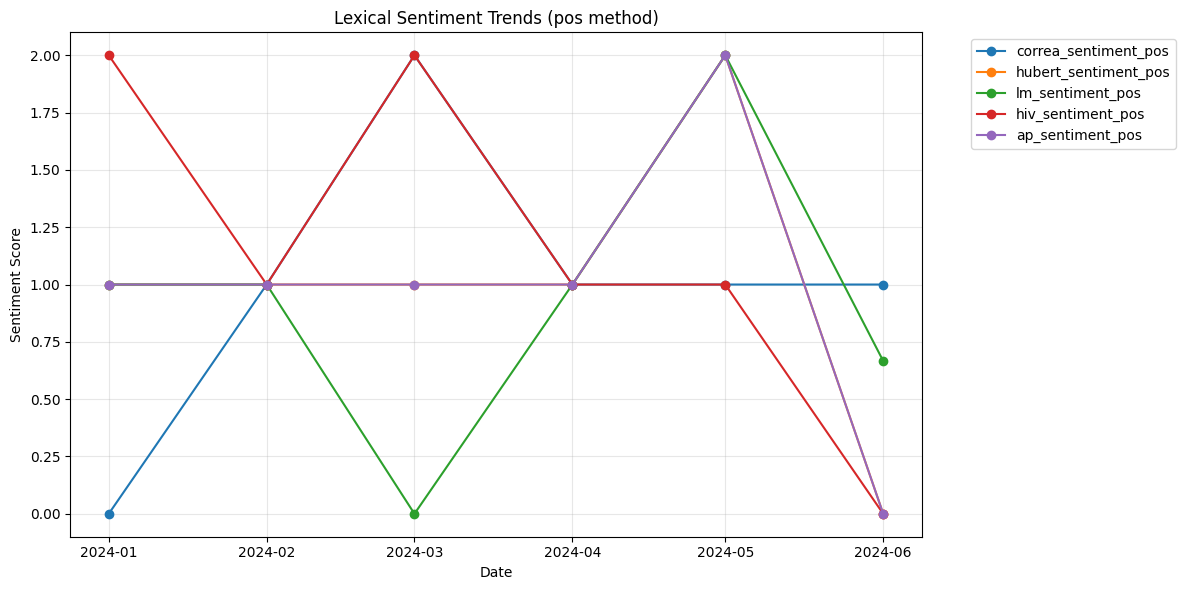

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
for col in [c for c in sentiment_columns if 'pos' in c and 'stem' not in c]:
    plt.plot(df_final['date'], df_final[col], label=col, marker='o')

plt.title('Lexical Sentiment Trends (pos method)')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparison: Stemming vs. Non-Stemming

Lexical dictionaries can be applied to either raw tokens or stemmed tokens. Stemming can improve coverage by matching variations of words (e.g., "growth", "growing", "grew") to the same root in the dictionary.

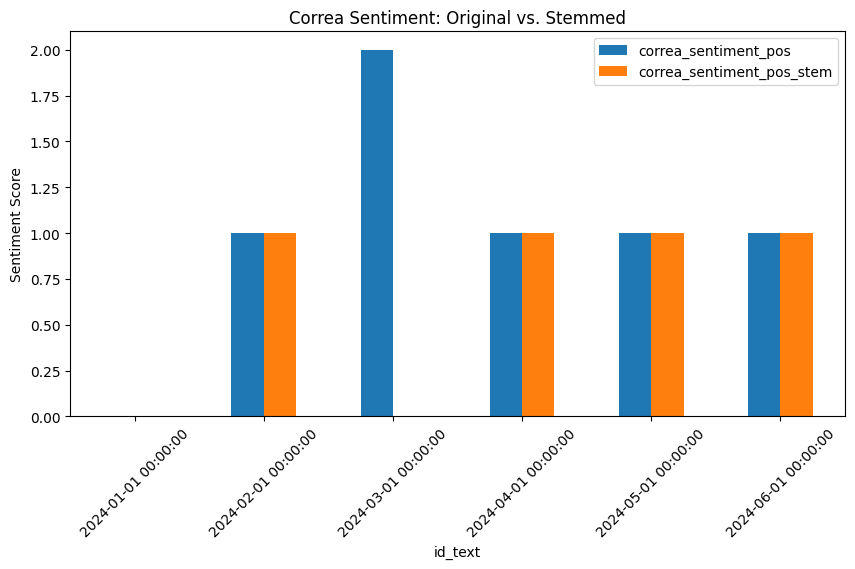

In [78]:
# Compare Correa sentiment with and without stemming
stem_cols = ['correa_sentiment_pos', 'correa_sentiment_pos_stem']
df_final[stem_cols].plot(kind='bar', figsize=(10, 5))
plt.title('Correa Sentiment: Original vs. Stemmed')
plt.ylabel('Sentiment Score')
plt.xticks(range(len(df_final)), df_final['date'], rotation=45)
plt.show()

## Loading Previously Exported Results

Once the pipeline has been run, the results are stored in the export path. You can load them directly for further analysis without re-running the analysis.

In [51]:
# # Load the full sentiment results
# export_path = "data/temp/lexical_results"
# df_results = pd.read_csv(f"{export_path}/sentiment_all_results.csv")

# # Load just the lexical components
# df_lexical_only = pd.read_csv(f"{export_path}/sentiment_lexical.csv")

# print(f"Loaded results shape: {df_results.shape}")
# df_results.head()

## Conclusion

In this notebook, we demonstrated how the `AutoEconSentiment` library simplifies lexical sentiment analysis. By providing a unified interface for multiple dictionaries and aggregation methods, it allows researchers to easily compare different sentiment metrics and robustly analyze economic texts.